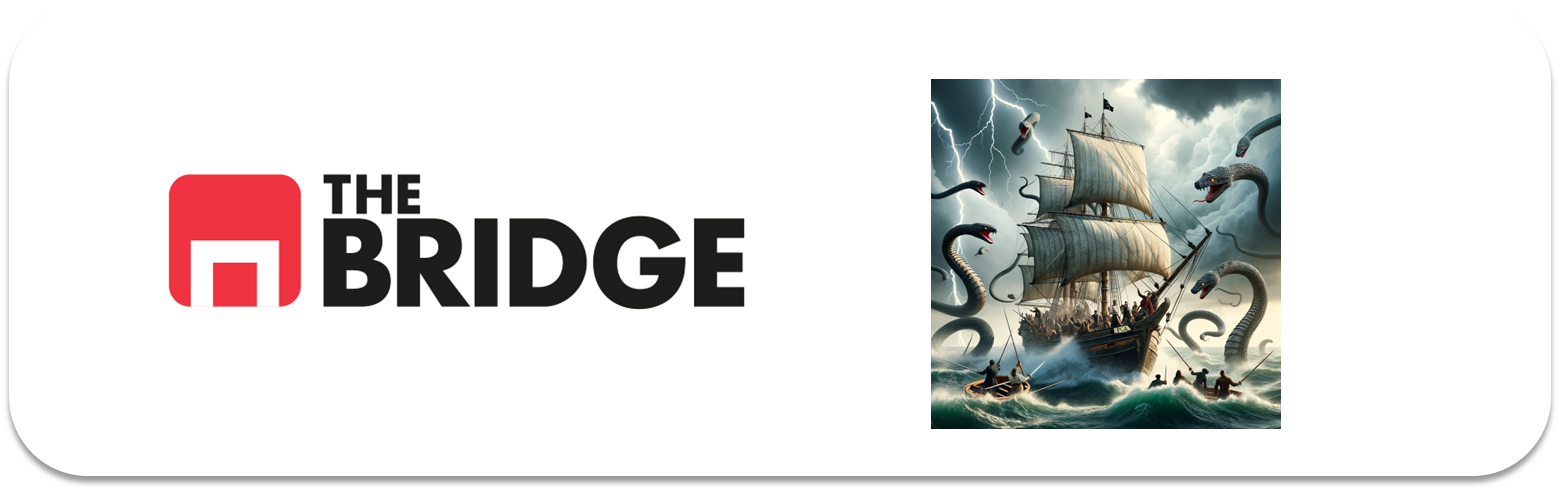

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos base
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Selección de features
from sklearn.feature_selection import (
    SelectKBest, 
    chi2, 
    f_classif, 
    mutual_info_classif,
    RFE
)

# Métodos basados en modelos
from sklearn.linear_model import Lasso
from sklearn.ensemble import ExtraTreesClassifier

# Ignorar warnings molestos
import warnings
warnings.filterwarnings("ignore")

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [3]:
# Carga de datos
df = pd.read_csv("./data/credit_npo.csv")
df.head()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


### 1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

In [4]:
df = df.dropna()

# Ejemplo de variables tipo NumberOf...
num_to_cat_cols = [
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents'
]

def binarize_count(x, max_bin=2):
    # 0, 1, >=2
    return np.where(x == 0, 0, np.where(x == 1, 1, max_bin))

for col in num_to_cat_cols:
    if col in df.columns:
        df[col + "_cat"] = binarize_count(df[col])
        df[col + "_cat"] = df[col + "_cat"].astype("category")

# Definimos target y features
target = 'SeriousDlqin2yrs'
X = df.drop(columns=[target])
y = df[target]

# Separar numéricas y categóricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['category', 'object', 'bool']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 

1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.

Lista 1 - Top correlación: ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'age', 'NumberOfDependents']


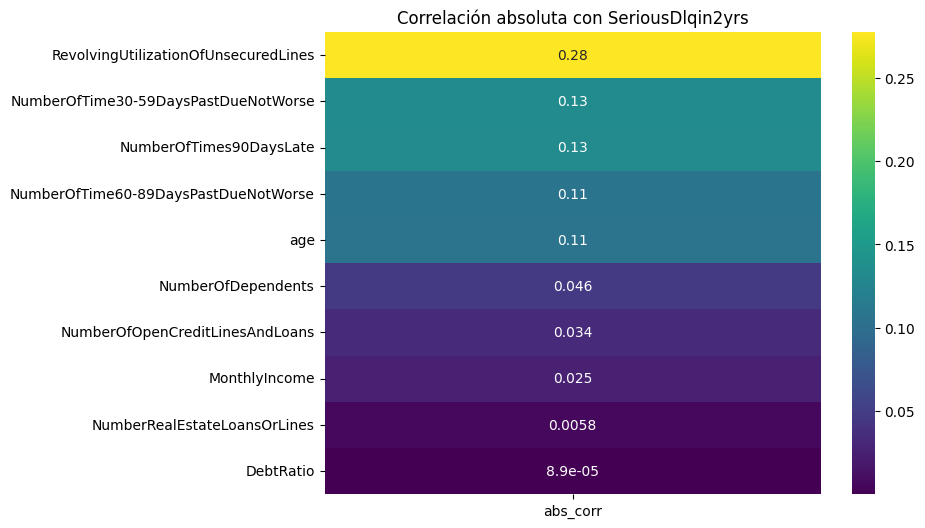

In [7]:
# Correlación con la variable objetivo (solo numéricas)
corr = pd.concat([X_train[num_cols], y_train], axis=1).corr()[target].drop(target)

# Ordenar por correlación absoluta
corr_abs = corr.abs().sort_values(ascending=False)

# Top 6 variables más correlacionadas
top_corr_features = corr_abs.head(6).index.tolist()
print("Lista 1 - Top correlación:", top_corr_features)

# Mapa de calor opcional
plt.figure(figsize=(8,6))
sns.heatmap(corr_abs.to_frame("abs_corr"), annot=True, cmap="viridis")
plt.title("Correlación absoluta con SeriousDlqin2yrs")
plt.show()

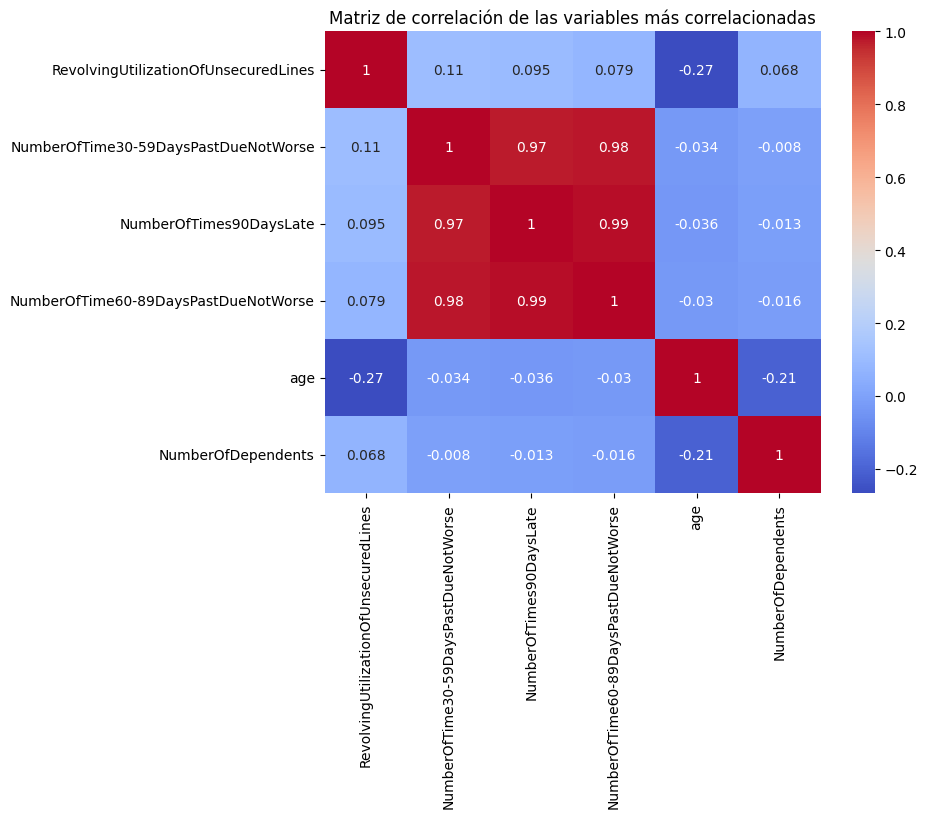

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(X_train[top_corr_features].corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación de las variables más correlacionadas")
plt.show()

In [31]:
top_corr_features

['RevolvingUtilizationOfUnsecuredLines',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfTimes90DaysLate',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'age',
 'NumberOfDependents']

2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 

In [35]:
# -----------------------------------------
# 4.1 NUMÉRICAS CON ANOVA + FILTRO CORRELACIÓN
# -----------------------------------------

# 1. Calculamos correlación entre numéricas
corr_matrix = X_train[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 2. Detectamos variables redundantes (correlación > 0.90)
redundant = [col for col in upper.columns if any(upper[col] > 0.90)]
print("Variables redundantes por correlación:", redundant)

# 3. Eliminamos redundantes ANTES de SelectKBest
num_cols_filtered = [c for c in num_cols if c not in redundant]

# 4. SelectKBest ANOVA sobre numéricas filtradas
skb_num = SelectKBest(score_func=f_classif, k=min(6, len(num_cols_filtered)))
skb_num.fit(X_train[num_cols_filtered], y_train)

scores_num = pd.Series(skb_num.scores_, index=num_cols_filtered).sort_values(ascending=False)
top_num_anova = scores_num.head(6).index.tolist()
print("Top numéricas ANOVA (filtradas):", top_num_anova)


# -----------------------------------------
# 4.2 CATEGÓRICAS CON MUTUAL INFORMATION
# -----------------------------------------

if len(cat_cols) > 0:
    X_train_cat_codes = X_train[cat_cols].apply(lambda s: s.cat.codes)
    mi = mutual_info_classif(X_train_cat_codes, y_train, discrete_features=True)
    mi_scores = pd.Series(mi, index=cat_cols).sort_values(ascending=False)
    top_cat_mi = mi_scores.head(6).index.tolist()
else:
    top_cat_mi = []

print("Top categóricas MI:", top_cat_mi)


# -----------------------------------------
# 4.3 COMBINACIÓN + FILTRO DE CORRELACIÓN FINAL
# -----------------------------------------

ordered = top_num_anova + top_cat_mi
selected = []

for feat in ordered:
    if len(selected) >= 6:
        break

    too_corr = False
    for s in selected:
        if abs(X_train[[feat, s]].corr().iloc[0, 1]) > 0.90:
            too_corr = True
            break

    if not too_corr:
        selected.append(feat)

list2_features = selected
print("Lista 2 - SelectKBest (ANOVA + MI, decorrelada):", list2_features)

Variables redundantes por correlación: ['NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']
Top numéricas ANOVA (filtradas): ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'age', 'NumberOfDependents', 'NumberOfOpenCreditLinesAndLoans', 'MonthlyIncome']
Top categóricas MI: ['NumberOfTimes90DaysLate_cat', 'NumberOfTime30-59DaysPastDueNotWorse_cat', 'NumberOfTime60-89DaysPastDueNotWorse_cat', 'NumberOfOpenCreditLinesAndLoans_cat', 'NumberRealEstateLoansOrLines_cat', 'NumberOfDependents_cat']
Lista 2 - SelectKBest (ANOVA + MI, decorrelada): ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'age', 'NumberOfDependents', 'NumberOfOpenCreditLinesAndLoans', 'MonthlyIncome']


3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)

In [37]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 1. Codificamos todas las variables categóricas
X_train_enc = pd.get_dummies(X_train, drop_first=True)

# 2. Definimos el modelo intermedio
base_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# 3. SelectFromModel con máximo 6 features
sfm = SelectFromModel(base_model, max_features=6)
sfm.fit(X_train_enc, y_train)

# 4. Extraemos las columnas seleccionadas
selected_features_sfm = X_train_enc.columns[sfm.get_support()].tolist()

print("Features seleccionadas por SelectFromModel:")
print(selected_features_sfm)

Features seleccionadas por SelectFromModel:
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']


In [39]:
df.head(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,NumberOfOpenCreditLinesAndLoans_cat,NumberOfTimes90DaysLate_cat,NumberRealEstateLoansOrLines_cat,NumberOfTime30-59DaysPastDueNotWorse_cat,NumberOfTime60-89DaysPastDueNotWorse_cat,NumberOfDependents_cat
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0,2,1,0,0,0,0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0,2,0,1,0,0,0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0,2,0,0,0,0,2
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0,2,0,2,0,0,2
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0,2,0,0,0,0,1
5,0,0.101002,61,0,0.217115,15880.0,5,0,1,0,0.0,2,0,1,0,0,0
6,0,0.222830,60,0,0.907083,1312.0,5,0,0,0,0.0,2,0,0,0,0,0
7,0,0.353443,39,0,0.764309,4000.0,11,0,1,0,2.0,2,0,1,0,0,2
8,0,0.772455,45,0,0.387179,5100.0,5,0,1,0,3.0,2,0,1,0,0,2
9,0,0.116165,44,0,0.160236,10833.0,8,0,1,0,0.0,2,0,1,0,0,0


In [40]:
df['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    10986
1      830
Name: count, dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11816 entries, 0 to 12536
Data columns (total 17 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   SeriousDlqin2yrs                          11816 non-null  int64   
 1   RevolvingUtilizationOfUnsecuredLines      11816 non-null  float64 
 2   age                                       11816 non-null  int64   
 3   NumberOfTime30-59DaysPastDueNotWorse      11816 non-null  int64   
 4   DebtRatio                                 11816 non-null  float64 
 5   MonthlyIncome                             11816 non-null  float64 
 6   NumberOfOpenCreditLinesAndLoans           11816 non-null  int64   
 7   NumberOfTimes90DaysLate                   11816 non-null  int64   
 8   NumberRealEstateLoansOrLines              11816 non-null  int64   
 9   NumberOfTime60-89DaysPastDueNotWorse      11816 non-null  int64   
 10  NumberOfDependents         

4. Selección de las mejores features empleando RFE.

In [42]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# 1. Codificamos categóricas como códigos (NO dummies)
X_train_enc = X_train.copy()
for c in cat_cols:
    X_train_enc[c] = X_train_enc[c].cat.codes

# 2. Modelo base para RFE
model_rfe = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# 3. RFE con máximo 6 features
rfe = RFE(estimator=model_rfe, n_features_to_select=6)
rfe.fit(X_train_enc, y_train)

raw_rfe_features = X_train_enc.columns[rfe.get_support()].tolist()
print("RFE sin filtrar:", raw_rfe_features)

# ---------------------------------------------------
# 4. Filtro de correlación para evitar redundancias
# ---------------------------------------------------

selected = []

for feat in raw_rfe_features:
    if len(selected) >= 6:
        break

    too_corr = False
    for s in selected:
        corr = abs(np.corrcoef(X_train_enc[feat], X_train_enc[s])[0,1])
        if corr > 0.90:
            too_corr = True
            break

    if not too_corr:
        selected.append(feat)

list4_features = selected

print("\nLista 4 - RFE (decorrelada):")
print(list4_features)

RFE sin filtrar: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']

Lista 4 - RFE (decorrelada):
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']


5. Selección de las mejores features empleando SFS.

In [44]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# 1. Codificamos categóricas como dummies (LogReg lo necesita)
X_train_enc = pd.get_dummies(X_train, drop_first=True)

# 2. Modelo base para SFS
model_sfs = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='liblinear'
)

# 3. SFS forward seleccionando máximo 6 features
sfs = SequentialFeatureSelector(
    model_sfs,
    n_features_to_select=6,
    direction='forward',
    n_jobs=-1
)

sfs.fit(X_train_enc, y_train)

raw_sfs_features = X_train_enc.columns[sfs.get_support()].tolist()
print("SFS sin filtrar:", raw_sfs_features)

# ---------------------------------------------------
# 4. Filtro de correlación para evitar redundancias
# ---------------------------------------------------

selected = []

for feat in raw_sfs_features:
    if len(selected) >= 6:
        break

    too_corr = False
    for s in selected:
        corr = abs(np.corrcoef(X_train_enc[feat], X_train_enc[s])[0,1])
        if corr > 0.90:
            too_corr = True
            break

    if not too_corr:
        selected.append(feat)

list5_features = selected

print("\nLista 5 - SFS (decorrelada):")
print(list5_features)

SFS sin filtrar: ['NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate_cat_2', 'NumberRealEstateLoansOrLines_cat_1', 'NumberRealEstateLoansOrLines_cat_2', 'NumberOfTime60-89DaysPastDueNotWorse_cat_2', 'NumberOfDependents_cat_1']

Lista 5 - SFS (decorrelada):
['NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate_cat_2', 'NumberRealEstateLoansOrLines_cat_1', 'NumberRealEstateLoansOrLines_cat_2', 'NumberOfTime60-89DaysPastDueNotWorse_cat_2', 'NumberOfDependents_cat_1']


6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

In [45]:
list6_features = list(
    set(top_corr_features)
    & set(list2_features)
    & set(selected_features_sfm)
    & set(list4_features)
    & set(list5_features)
)

print("L6 - Intersección:", list6_features)

L6 - Intersección: []


In [46]:
from collections import Counter

# Diccionario con tus listas (asegúrate de que están guardadas)
feature_sets = {
    "L1_corr": top_corr_features,
    "L2_skb": list2_features,
    "L3_sfm": selected_features_sfm,   # ← AQUÍ VA TU LISTA
    "L4_rfe": list4_features,
    "L5_sfs": list5_features,
    "L6_vote": list6_features
}

# 1. Unimos todas las listas en una sola
all_features = []
for key, feats in feature_sets.items():
    all_features.extend(feats)

# 2. Contamos votos
votes = Counter(all_features)

# 3. Ordenamos por número de votos (de mayor a menor)
sorted_votes = votes.most_common()

print("Votos por feature:")
for feat, v in sorted_votes:
    print(f"{feat}: {v}")

# 4. Seleccionamos las 6 más votadas
list6_voting = [feat for feat, v in sorted_votes[:6]]

print("\nLista 6 - Voting (Top 6 features):")
print(list6_voting)

Votos por feature:
RevolvingUtilizationOfUnsecuredLines: 4
NumberOfTime30-59DaysPastDueNotWorse: 4
age: 4
NumberOfOpenCreditLinesAndLoans: 4
MonthlyIncome: 3
NumberOfDependents: 2
DebtRatio: 2
NumberOfTimes90DaysLate: 1
NumberOfTime60-89DaysPastDueNotWorse: 1
NumberOfTimes90DaysLate_cat_2: 1
NumberRealEstateLoansOrLines_cat_1: 1
NumberRealEstateLoansOrLines_cat_2: 1
NumberOfTime60-89DaysPastDueNotWorse_cat_2: 1
NumberOfDependents_cat_1: 1

Lista 6 - Voting (Top 6 features):
['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'age', 'NumberOfOpenCreditLinesAndLoans', 'MonthlyIncome', 'NumberOfDependents']


### 3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

In [52]:
feature_sets["L6_vote"] = [
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'age',
    'NumberOfOpenCreditLinesAndLoans',
    'MonthlyIncome',
    'NumberOfDependents'
]

In [53]:
feature_sets["L5_sfs"] = [
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents'
]

In [54]:
for name, feats in feature_sets.items():
    print(name, feats)

L1_corr ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'age', 'NumberOfDependents']
L2_skb ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'age', 'NumberOfDependents', 'NumberOfOpenCreditLinesAndLoans', 'MonthlyIncome']
L3_sfm ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']
L4_rfe ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']
L5_sfs ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
L6_vote ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'age', 'NumberOfOpenCreditLinesAn

In [55]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd

# 1. Definimos los modelos
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear"
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1])),
        random_state=42,
        n_jobs=-1
    )
}

# 2. Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Evaluación
results = []

for list_name, features in feature_sets.items():
    X_sel = X_train[features]   # ← ahora todas las columnas existen

    for model_name, model in models.items():
        scores = cross_val_score(
            model,
            X_sel,
            y_train,
            cv=cv,
            scoring="recall"
        )
        results.append({
            "Feature_Set": list_name,
            "Model": model_name,
            "Recall_mean": scores.mean(),
            "Recall_std": scores.std()
        })

# 4. Convertimos a DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Recall_mean", ascending=False)

print(results_df)

   Feature_Set               Model  Recall_mean  Recall_std
6       L3_sfm  LogisticRegression     0.742470    0.021985
3       L2_skb  LogisticRegression     0.742470    0.021985
9       L4_rfe  LogisticRegression     0.742470    0.021985
15     L6_vote  LogisticRegression     0.740966    0.019906
12      L5_sfs  LogisticRegression     0.733390    0.017600
0      L1_corr  LogisticRegression     0.722898    0.008522
14      L5_sfs             XGBoost     0.631055    0.024711
2      L1_corr             XGBoost     0.620540    0.047507
17     L6_vote             XGBoost     0.578287    0.032931
5       L2_skb             XGBoost     0.576771    0.035180
8       L3_sfm             XGBoost     0.558669    0.036623
11      L4_rfe             XGBoost     0.558669    0.036623
13      L5_sfs        RandomForest     0.242550    0.028707
1      L1_corr        RandomForest     0.177831    0.041266
4       L2_skb        RandomForest     0.063249    0.016864
7       L3_sfm        RandomForest     0

In [56]:
# Codificamos test igual que train
X_test_enc = pd.get_dummies(X_test, drop_first=True)

# Alineamos columnas (muy importante)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

In [57]:
X_train_sfm = X_train_enc[selected_features_sfm]
X_test_sfm = X_test_enc[selected_features_sfm]

#### Seleccionamos las mejores features

In [58]:
best_features = feature_sets["L3_sfm"]

X_train_best = X_train_enc[best_features]
X_test_best = X_test_enc[best_features]


### 4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.

In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": ["balanced"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_best, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor recall en CV:", grid.best_score_)

Mejores hiperparámetros: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Mejor recall en CV: 0.7439280018227387


In [60]:
best_model = grid.best_estimator_
best_model.fit(X_train_best, y_train)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=2000, penalty='l1',
                   solver='liblinear')

In [61]:
from sklearn.metrics import classification_report, recall_score

y_pred = best_model.predict(X_test_best)

print("Recall en test:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Recall en test: 0.7108433734939759
              precision    recall  f1-score   support

           0       0.97      0.77      0.86      2198
           1       0.19      0.71      0.30       166

    accuracy                           0.76      2364
   macro avg       0.58      0.74      0.58      2364
weighted avg       0.92      0.76      0.82      2364



### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

#### 1. Estandarizar los datos

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

#### 2. Aplicar PCA y ver varianza

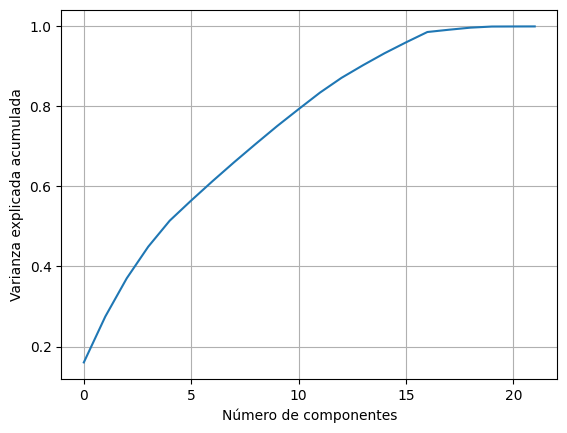

In [63]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA().fit(X_train_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.grid(True)
plt.show()

#### 3. elegir nº componentes

In [64]:
pca = PCA(n_components=8)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

#### 4. Entrenar modelo ganador

In [65]:
from sklearn.linear_model import LogisticRegression

pca_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear"
)

pca_model.fit(X_train_pca, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, solver='liblinear')

#### 5. Evaluar en test

In [66]:
from sklearn.metrics import recall_score, classification_report

y_pred_pca = pca_model.predict(X_test_pca)

print("Recall en test (PCA):", recall_score(y_test, y_pred_pca))
print(classification_report(y_test, y_pred_pca))

Recall en test (PCA): 0.6566265060240963
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      2198
           1       0.23      0.66      0.35       166

    accuracy                           0.83      2364
   macro avg       0.60      0.75      0.62      2364
weighted avg       0.92      0.83      0.86      2364



Resumen del resultado con PCA

 Tras aplicar PCA y entrenar una regresión logística sobre los componentes principales, el modelo obtuvo en test un recall de 0.65. Esto significa que el modelo con PCA detecta aproximadamente el 66% de los morosos, un rendimiento inferior al modelo original sin PCA, que alcanzaba un recall del 71%.

 En el informe de clasificación, la clase minoritaria (morosos) mantiene un recall razonable, pero pierde capacidad predictiva respecto al modelo sin reducción de dimensionalidad.


Conclusiones
- PCA reduce el rendimiento del modelo en este problema, especialmente en la detección de la clase minoritaria.
- Esto es esperable porque PCA maximiza la varianza total, no la información relevante para separar morosos de no morosos.
- Aunque PCA simplifica el dataset y reduce dimensionalidad, pierde señales importantes para identificar correctamente a los clientes con riesgo de impago.
- Por tanto, el modelo original con selección de características (L3_sfm) sigue siendo la mejor opción, ya que conserva la estructura de las variables más informativas.
